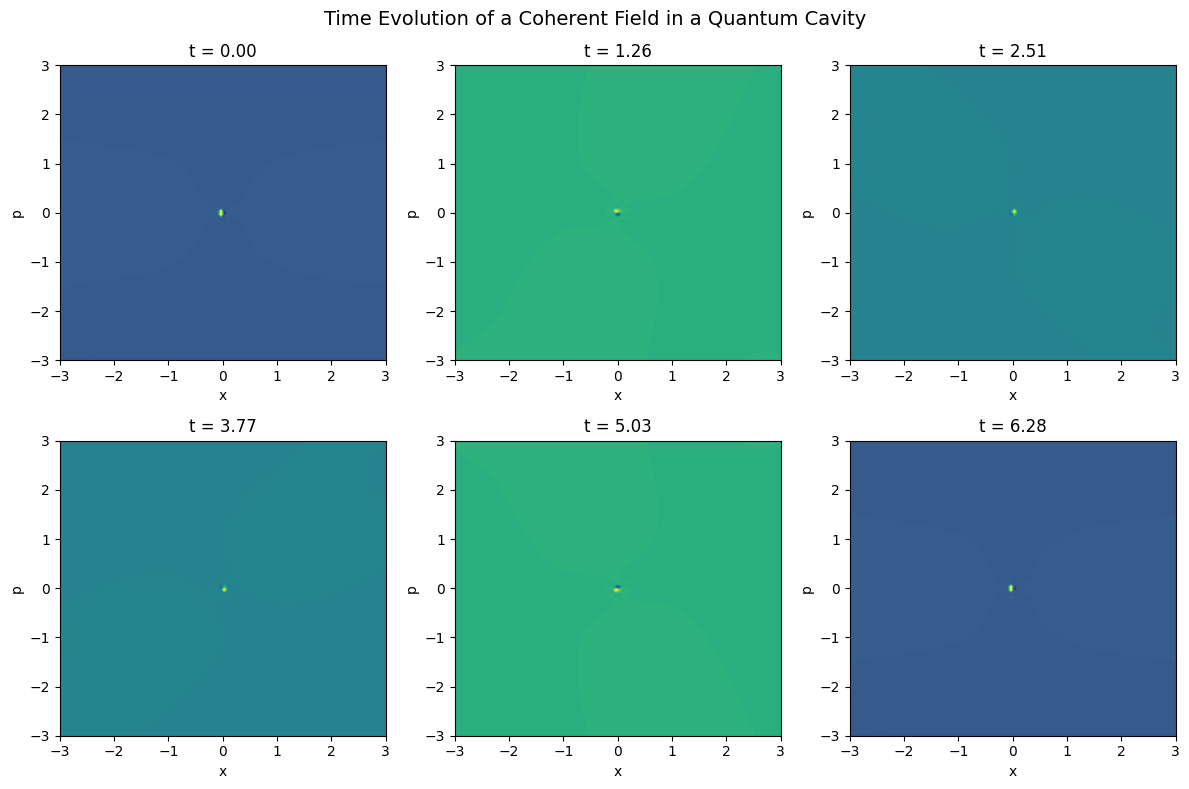

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
from qiskit.quantum_info import Statevector

# --- Step 1: Define constants ---
omega = 1.0        # frequency of the cavity mode
n_max = 10         # photon number cutoff
times = np.linspace(0, 2*np.pi/omega, 6)  # 6 time steps

# --- Step 2: Define initial coherent state (alpha = 1) ---
alpha = 1.0
coeffs = np.array([np.exp(-abs(alpha)**2/2) * (alpha**n) / np.sqrt(factorial(n)) for n in range(n_max)])
psi0 = Statevector(coeffs)

# --- Step 3: Function to compute manual Wigner function ---
def wigner_function_manual(psi, x, p):
    X, P = np.meshgrid(x, p)
    rho = np.outer(psi.data, np.conj(psi.data))
    W = np.zeros_like(X, dtype=float)

    for m in range(len(psi)):
        for n in range(len(psi)):
            coeff = rho[m, n] * ((-1)**n) / np.sqrt(factorial(m) * factorial(n))
            W += np.real(coeff * np.exp(- (X**2 + P**2)) * (X + 1j*P)**(m - n))

    return W / np.pi

# --- Step 4: Plot Wigner functions for different times ---
x = np.linspace(-3, 3, 100)
p = np.linspace(-3, 3, 100)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, t in enumerate(times):
    phase_factors = np.exp(-1j * omega * np.arange(n_max) * t)
    psi_t = Statevector(coeffs * phase_factors)
    W = wigner_function_manual(psi_t, x, p)
    axes[i].contourf(x, p, W, levels=80, cmap='viridis')
    axes[i].set_title(f"t = {t:.2f}")
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("p")

plt.suptitle("Time Evolution of a Coherent Field in a Quantum Cavity", fontsize=14)
plt.tight_layout()
plt.show()
